Link ka datasetu: https://www.kaggle.com/datasets/miadul/credit-card-fraud-detection-dataset

In [1]:
import pandas as pd
import torch

In [62]:
df = pd.read_csv("credit_card_fraud_10k.csv")
df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [63]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB


In [64]:
print(df['merchant_category'].value_counts())

merchant_category
Food           2093
Clothing       2050
Travel         1990
Grocery        1944
Electronics    1923
Name: count, dtype: int64


In [65]:
# Izbacujemo jedinstvene identifikatore iz razloga jer nemaju nikakvu prediktivnu moc
df = df.drop(columns=['transaction_id'])

In [66]:
df.head(30)


,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,84.47,22,Electronics,0,0,66,3,40,0
1,541.82,3,Travel,1,0,87,1,64,0
2,237.01,17,Grocery,0,0,49,1,61,0
3,164.33,4,Grocery,0,1,72,3,34,0
4,30.53,15,Food,0,0,79,0,44,0
5,30.53,13,Clothing,0,0,90,2,46,0
6,10.77,18,Travel,0,0,48,1,28,0
7,362.02,13,Electronics,0,0,68,1,40,0
8,165.43,8,Grocery,0,0,80,0,21,0
9,221.63,5,Grocery,0,0,59,1,34,0


In [67]:
# Koristimo One-Hot Encoding za prebacivanje u numericku, posto je tip object, a bice nam korisna kolona.
df = pd.get_dummies(df, columns=['merchant_category'], drop_first=True, dtype=int)

In [68]:
df.head(30)


,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud,merchant_category_Electronics,merchant_category_Food,merchant_category_Grocery,merchant_category_Travel
0,84.47,22,0,0,66,3,40,0,1,0,0,0
1,541.82,3,1,0,87,1,64,0,0,0,0,1
2,237.01,17,0,0,49,1,61,0,0,0,1,0
3,164.33,4,0,1,72,3,34,0,0,0,1,0
4,30.53,15,0,0,79,0,44,0,0,1,0,0
5,30.53,13,0,0,90,2,46,0,0,0,0,0
6,10.77,18,0,0,48,1,28,0,0,0,0,1
7,362.02,13,0,0,68,1,40,0,1,0,0,0
8,165.43,8,0,0,80,0,21,0,0,0,1,0
9,221.63,5,0,0,59,1,34,0,0,0,1,0


In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   amount                         10000 non-null  float64
 1   transaction_hour               10000 non-null  int64  
 2   foreign_transaction            10000 non-null  int64  
 3   location_mismatch              10000 non-null  int64  
 4   device_trust_score             10000 non-null  int64  
 5   velocity_last_24h              10000 non-null  int64  
 6   cardholder_age                 10000 non-null  int64  
 7   is_fraud                       10000 non-null  int64  
 8   merchant_category_Electronics  10000 non-null  int64  
 9   merchant_category_Food         10000 non-null  int64  
 10  merchant_category_Grocery      10000 non-null  int64  
 11  merchant_category_Travel       10000 non-null  int64  
dtypes: float64(1), int64(11)
memory usage: 937.6 KB

In [70]:
import numpy as np


#Sada pravimo ulaze i izlaze. Logicno posto predvidjamo prevare izlaz ce nam biti kolona is_fraudlent, dok su ulazi sve ostale promenljive.
X = df.drop(columns=['is_fraud']).values.astype(np.float32)
y = df['is_fraud'].values.astype(np.float32)

In [71]:
from sklearn.model_selection import train_test_split
#U ovom delu smo napravili podelu na trening, validacioni i test skup. Na trening delu model uci podatke, validacioni skup služi za praćenje rada mreže tokom samog treninga na kraju epoha, dok test skup nam samom kraju nam daje realnu ocenu za nas model.
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=42, stratify=y_train_val
)

In [72]:
from sklearn.preprocessing import StandardScaler
#Sada skaliramo vrednosti nasih ulaznih parametara, zato sto nam je prvobitno veliki raspon izmedju vrednosti.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [73]:
from torch.utils.data import TensorDataset
#Potrebno je sve brojeve da pretvorimo u tenzore jer neurosnke mreze znaju samo sa njima da rade. Preko tensordataset pravimo dataset koji nam spaja po redovima ulaze i izlazne varijable.
train_dataset = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
val_dataset = TensorDataset(torch.tensor(X_val), torch.tensor(y_val))
test_dataset = TensorDataset(torch.tensor(X_test), torch.tensor(y_test))

In [74]:
from torch.utils.data import DataLoader
#Pakujemo sve u dataloader koji kontrolise kako podaci dolaze do mreze. Zahvaljujuci njemu ne saljemo sve transakcije odjenom, nego u paketima(ovde od po 64 transakcije). Na trening delu mesamo podatke, dok na val i test nema potrebe.
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

Arhitektura

In [75]:

import torch.nn as nn

class FraudDetectionClass(nn.Module):

    def __init__(self, input_dim, hidden1=64, hidden2=32, dropout_rate=0.3):
        #Povezujemo nasu klasu sa klasom nn.Module i nasledjujemo sve njene ugradjene funkcije
        super().__init__()

        # nn.Sequential spaja slojeve u jedan niz
        self.network = nn.Sequential(
            # Prvi skriveni sloj: ulazni atribut  hidden1
            # Linear radi po principu gledanja vaznosti svakog podatka. On dodeljuje tezinu podacima i pravi linearnsu jednacinu.
            # Nije mnogo pametan sam i moramo ukonbinovati sa jos nekim modelom
            nn.Linear(input_dim, hidden1),
            #Relu je aktivaciona funkcija i njen  zadatak je da unese nelinearnost u mrežu. Ako je broj <=0 upisuje ga kao 0, ako je veci ostaje nepromenjen
            nn.ReLU(),
            # 3. Nasumično ugasi neke od sumnjivih signala da mreža ne bi varala
            nn.Dropout(dropout_rate),

            # Drugi skriveni sloj: hidden1, hidden2
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # Izlazni sloj: hidden2,  1 (binarna klasifikacija)
            nn.Linear(hidden2, 1)
        )

    def forward(self, x):
        # Podaci samo prolaze kroz ceo sekvencijalni niz odjednom. Funkcija se sama poziva.
        return self.network(x)

In [76]:
# Saznajemo broj kolona iz našeg pripremljenog X_train
input_features_count = X_train.shape[1]
#Pozivamo nasu klasu i prosledjujemo dimeznije naseg xtrain
model_default = FraudDetectionClass(input_dim=input_features_count)
print(model_default)

FraudDetectionClass(
  (network): Sequential(
    (0): Linear(in_features=11, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


Trening


In [77]:
import torch.optim as optim

# DEFINISANJE FUNKCIJE GREŠKE
#Pošto imamo samo dve klase , koristimo Binary Cross Entropy. Ona strogo kažnjava model ako je bio siguran u pogrešan odgovor.
#Ova funkcija greške u sebi ima ugrađenu Sigmoid funkciju. Ona uzme taj sirovi broj, provuče ga kroz Sigmoid da dobije procenat, i odmah izračuna grešku.
# Računamo odnos klasa iz TRENING skupa (ne iz celog dataseta, da izbegnemo data leakage)



criterion = nn.BCEWithLogitsLoss()


# DEFINISANJE OPTIMIZATORA
# Optimizatori popravljaju model. Adam ima adaptivnu stopu učenja. On prati koliko se koja težina brzo menja. Ako je neki parametar prebrz, Adam će smanjiti korak da ne bi preskočio rešenje. Ako se neka težina jedva pomera, on će povećati brzinu da bi ubrzao učenje
optimizer = optim.Adam(model_default.parameters(), lr=0.001)

print("Loss funkcija i Optimizator su uspešno definisani!")
print(f"Izabrana funkcija greške: {criterion.__class__.__name__}")
# Pristupamo nazivu klase unutar optimizatora radi lepog ispisa
print(f"Izabrani optimizator: {optimizer.__class__.__name__} sa lr=0.001")

Loss funkcija i Optimizator su uspešno definisani!
Izabrana funkcija greške: BCEWithLogitsLoss
Izabrani optimizator: Adam sa lr=0.001


In [78]:
class EarlyStopping:
    def __init__(self, patience=5, delta=0.0):
        self.patience = patience
        self.delta = delta

        self.best_loss = float("inf")
        self.no_improvement_count = 0
        self.stop_training = False

    def check_early_stop(self, val_loss, model):
        if val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.no_improvement_count = 0
            # Čuvanje modela
            torch.save(model.state_dict(), "best_model_early_stopping.pth")
            print(f"Validacioni gubitak se smanjio na {val_loss:.4f}. Model je sačuvan.")
        else:
            self.no_improvement_count += 1
            print(f"EarlyStopping brojač: {self.no_improvement_count} od {self.patience}")
            if self.no_improvement_count >= self.patience:
                self.stop_training = True
                print("Early stopping aktiviran.")

In [79]:
early_stopping = EarlyStopping(patience=5, delta=0.0)

In [80]:
EPOCHS = 50
train_losses = []
val_losses = []

print("Započinjemo trening neuronske mreže...\n")
#Broji od 1 do 50
for epoch in range(1, EPOCHS + 1):

    model_default.train()
    #Resetuje brojač ukupne greške na nulu na početku svake epohe. Tu ćemo sabirati greške iz svakog pojedinačnog paketa (batch-a).
    running_train_loss = 0.0
    #train_loader uzima naše podatke i isporučuje ih u paketima. U svakom krugu ove petlje, X_batch dobija tačno 64 transakcije, a y_batch dobija njihovih 64 tačnih odgovora (0 ili 1).
    for X_batch, y_batch in train_loader:
        #resetujemo greske kada dodju nove transakcije
        optimizer.zero_grad()
        #Šaljemo 64 transakcije u model. Pokreće se funkcija forward, podaci prolaze kroz Linear, ReLU i Dropout, a model vraća predikcije
        outputs = model_default(X_batch).squeeze(1)
        #Šaljemo predikcije modela (outputs) i tačne odgovore (y_batch) našoj funkciji greške. Ona računa koliko je model u ovom paketu od 64 transakcije bio blizu ili daleko od istine.
        loss = criterion(outputs, y_batch)
        #Ide od greske unazad i racuna koliko svaki pojedinacni parametar doprinsosi gresci
        loss.backward()
        #Adam optimizator uzima gradijente koji su izračunati u prethodnom koraku  i pomera težine za mali korak u smeru koji smanjuje grešku
        optimizer.step()
        #.item() pretvara PyTorch tenzor greške u običan Python broj. Množimo ga sa X_batch.size(0) (što je 64, odnosno broj elemenata u trenutnom paketu) da bismo dobili ukupan zbir greške za sve elemente u tom paketu i dodajemo ga na našu ukupnu sumu epohe (running_train_loss).
        running_train_loss += loss.item() * X_batch.size(0)
    #Kada prođu svi paketi, delimo ukupnu skupljenu grešku sa ukupnim brojem transakcija u celom trening skupu. Tako dobijamo prosečnu grešku po uzorku za tu epohu i upisujemo je u train_losses.
    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    # VALIDACIJA
    model_default.eval()
    running_val_loss = 0.0

    #Ne trosi memoriju na racunanje gradijenata
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs = model_default(X_batch).squeeze(1)
            loss = criterion(outputs, y_batch)
            running_val_loss += loss.item() * X_batch.size(0)

    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)

    # Ispis za trenutnu epohu
    print(f"Epoha [{epoch}/{EPOCHS}] -> Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")

    #Šaljemo joj trenutni epoch_val_loss i sam model. Klasa proverava ako je ovaj loss manji od dosadašnjeg najboljeg, ona ga proglasi za novi best_loss i sačuva trenutne težine u fajl best_model_early_stopping.pth. Ako nije manji, povećava brojač za 1.
    early_stopping.check_early_stop(epoch_val_loss, model_default)
    print("-" * 50)

    #  Proveravamo promenljivu stop_training iz klase
    if early_stopping.stop_training:
        print(f"\n[STOP] Trening je prekinut ranije u epohi {epoch}!")
        break

Započinjemo trening neuronske mreže...

Epoha [1/50] -> Train Loss: 0.2532 | Val Loss: 0.0792
Validacioni gubitak se smanjio na 0.0792. Model je sačuvan.
--------------------------------------------------
Epoha [2/50] -> Train Loss: 0.0758 | Val Loss: 0.0567
Validacioni gubitak se smanjio na 0.0567. Model je sačuvan.
--------------------------------------------------
Epoha [3/50] -> Train Loss: 0.0615 | Val Loss: 0.0456
Validacioni gubitak se smanjio na 0.0456. Model je sačuvan.
--------------------------------------------------
Epoha [4/50] -> Train Loss: 0.0503 | Val Loss: 0.0387
Validacioni gubitak se smanjio na 0.0387. Model je sačuvan.
--------------------------------------------------
Epoha [5/50] -> Train Loss: 0.0447 | Val Loss: 0.0343
Validacioni gubitak se smanjio na 0.0343. Model je sačuvan.
--------------------------------------------------
Epoha [6/50] -> Train Loss: 0.0386 | Val Loss: 0.0312
Validacioni gubitak se smanjio na 0.0312. Model je sačuvan.
---------------------

Analiza osetljivosti i hiperparametrska optimizacija

In [81]:
import time

# Definišemo tri različite konfiguracije za testiranje
konfiguracije = {
    "Model_1_Osnovni": {"hidden1": 64,  "hidden2": 32, "dropout": 0.3, "lr": 0.001, "fajl": "model_1_osnovni.pth"},
    "Model_2_Slozeni": {"hidden1": 128, "hidden2": 64, "dropout": 0.3, "lr": 0.001, "fajl": "model_2_slozeni.pth"},
    "Model_3_Manji": {"hidden1": 32,  "hidden2": 16, "dropout": 0.3, "lr": 0.001, "fajl": "model_3_manji.pth"},
    "Model_4_VeciDrouput": {"hidden1": 64,  "hidden2": 32, "dropout": 0.6, "lr": 0.001, "fajl": "model_4_vecidrouput.pth"},
    "Model_5_ManjiDrouput": {"hidden1": 64,  "hidden2": 32, "dropout": 0.1, "lr": 0.001, "fajl": "model_5_manjidropout.pth"},
    "Model_6_VeciLR": {"hidden1": 64,  "hidden2": 32, "dropout": 0.3, "lr": 0.01, "fajl": "model_6_vecilr.pth"},


}

# Rečnik u koji ćemo sačuvati rezultate gubitaka za grafikone
istorija_eksperimenata = {}
tabela_rezultata = []

input_features_count = X_train.shape[1]

for ime_modela, cfg in konfiguracije.items():
    print(f"\n Pokrećem trening za: {ime_modela} ({cfg['hidden1']} -> {cfg['hidden2']}, Dropout: {cfg['dropout']})")
    # ZABELEŽI VREME (Štoperica počinje)
    start_time = time.time()
    torch.manual_seed(42)

    # 1. Instanciranje modela sa specifičnim parametrima iz konfiguracije
    eksperiment_model = FraudDetectionClass(
        input_dim=input_features_count,
        hidden1=cfg["hidden1"],
        hidden2=cfg["hidden2"],
        dropout_rate=cfg["dropout"],

    )

    # 2. Definišemo optimizator i funkciju greške za ovaj model
    #klasna_tezina = torch.tensor([17.0])
    #criterion = nn.BCEWithLogitsLoss()
    # Računamo odnos klasa iz TRENING skupa

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(eksperiment_model.parameters(), lr=cfg["lr"])

    # 3. Inicijalizujemo EarlyStopping sa posebnim fajlom za ovaj model
    # Kreiramo privremenu potklasu da promenimo naziv fajla unutar check_early_stop ako je potrebno,


    early_stopping = EarlyStopping(patience=5, delta=0.0)

    t_losses = []
    v_losses = []

    for epoch in range(1, 30):
        eksperiment_model.train()
        running_t_loss = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = eksperiment_model(X_batch).squeeze(1)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            running_t_loss += loss.item() * X_batch.size(0)

        epoch_t_loss = running_t_loss / len(train_loader.dataset)
        t_losses.append(epoch_t_loss)

        eksperiment_model.eval()
        running_v_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                outputs = eksperiment_model(X_batch).squeeze(1)
                loss = criterion(outputs, y_batch)
                running_v_loss += loss.item() * X_batch.size(0)

        epoch_v_loss = running_v_loss / len(val_loader.dataset)
        v_losses.append(epoch_v_loss)

        early_stopping.check_early_stop(epoch_v_loss, eksperiment_model)

        if early_stopping.stop_training:
            print(f"-> [STOP] Prekinuto u epohi {epoch}.")
            break

    # RAČUNAMO VREME (Štoperica staje)
    elapsed = time.time() - start_time
    # Sačuvamo istoriju gubitaka za kasniju vizuelizaciju
    istorija_eksperimenata[ime_modela] = {
        "train_loss": t_losses,
        "val_loss": v_losses,
        "best_val_loss": early_stopping.best_loss
    }

    # Preimenujemo generisani fajl u ime specifično za taj model
    import os
    if os.path.exists("best_model_early_stopping.pth"):
        # Ako stari model sa ovim imenom već postoji od ranije, obriši ga
        if os.path.exists(cfg["fajl"]):
            os.remove(cfg["fajl"])

        os.rename("best_model_early_stopping.pth", cfg["fajl"])
    tabela_rezultata.append({
        "Konfiguracija": ime_modela,
        "Hidden": f"({cfg['hidden1']},{cfg['hidden2']})",
        "Dropout": cfg["dropout"],
        "Learning Rate": cfg["lr"],
        "Best Val Loss": early_stopping.best_loss,
        "Epohe": len(t_losses),
        "Vreme (s)": round(elapsed, 1)
    })

    print(f" Završen {ime_modela}. Najbolji Val Loss: {early_stopping.best_loss:.4f} | Vreme: {elapsed:.1f}s")
    print("-" * 60)


 Pokrećem trening za: Model_1_Osnovni (64 -> 32, Dropout: 0.3)
Validacioni gubitak se smanjio na 0.0792. Model je sačuvan.
Validacioni gubitak se smanjio na 0.0566. Model je sačuvan.
Validacioni gubitak se smanjio na 0.0479. Model je sačuvan.
Validacioni gubitak se smanjio na 0.0423. Model je sačuvan.
Validacioni gubitak se smanjio na 0.0381. Model je sačuvan.
Validacioni gubitak se smanjio na 0.0352. Model je sačuvan.
Validacioni gubitak se smanjio na 0.0317. Model je sačuvan.
Validacioni gubitak se smanjio na 0.0302. Model je sačuvan.
Validacioni gubitak se smanjio na 0.0282. Model je sačuvan.
Validacioni gubitak se smanjio na 0.0271. Model je sačuvan.
Validacioni gubitak se smanjio na 0.0257. Model je sačuvan.
EarlyStopping brojač: 1 od 5
Validacioni gubitak se smanjio na 0.0246. Model je sačuvan.
Validacioni gubitak se smanjio na 0.0245. Model je sačuvan.
Validacioni gubitak se smanjio na 0.0239. Model je sačuvan.
Validacioni gubitak se smanjio na 0.0238. Model je sačuvan.
Validac

In [82]:
# ISPIS FINALNE TABELE (Nakon što svi modeli završe)
# =====================================================================
df_rezultati = pd.DataFrame(tabela_rezultata)
# Sortiramo tabelu tako da najbolji model (najmanji loss) bude na prvom mestu
df_rezultati = df_rezultati.sort_values("Best Val Loss").reset_index(drop=True)

print("\n=== FINALNA TABELA REZULTATA (sortirano po Best Val Loss) ===")
print(df_rezultati.to_string(index=False))


=== FINALNA TABELA REZULTATA (sortirano po Best Val Loss) ===
       Konfiguracija   Hidden  Dropout  Learning Rate  Best Val Loss  Epohe  Vreme (s)
     Model_2_Slozeni (128,64)      0.3          0.001       0.014798     29        4.8
Model_5_ManjiDrouput  (64,32)      0.1          0.001       0.016426     29        4.1
     Model_1_Osnovni  (64,32)      0.3          0.001       0.019733     29        4.4
      Model_6_VeciLR  (64,32)      0.3          0.010       0.020058     18        2.6
       Model_3_Manji  (32,16)      0.3          0.001       0.024633     29        4.1
 Model_4_VeciDrouput  (64,32)      0.6          0.001       0.025147     27        3.9


In [83]:
# Definisanje kombinovane konfiguracije
ime_combo = "Model_7_Kombinovano"
cfg_combo = {"hidden1": 128, "hidden2": 64, "dropout": 0.1, "lr": 0.001, "fajl": "model_7_kombinovano.pth"}

print(f"Pokrećem trening za kombinovani model: {ime_combo} (hidden=(32,16), dropout=0.6, lr=0.001)")

# Startujemo štopericu i zaključavamo seed
start_time = time.time()
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Instanciranje modela sa ukrštenim parametrima
combo_model = FraudDetectionClass(
    input_dim=input_features_count,
    hidden1=cfg_combo["hidden1"],
    hidden2=cfg_combo["hidden2"],
    dropout_rate=cfg_combo["dropout"]
)
#klasna_tezina = torch.tensor([18.0])
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(combo_model.parameters(), lr=cfg_combo["lr"])
early_stopping = EarlyStopping(patience=5, delta=0.0)

t_losses = []
v_losses = []

for epoch in range(1, 30):
    combo_model.train()
    running_t_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = combo_model(X_batch).squeeze(1)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_t_loss += loss.item() * X_batch.size(0)

    epoch_t_loss = running_t_loss / len(train_loader.dataset)
    t_losses.append(epoch_t_loss)

    combo_model.eval()
    running_v_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs = combo_model(X_batch).squeeze(1)
            loss = criterion(outputs, y_batch)
            running_v_loss += loss.item() * X_batch.size(0)

    epoch_v_loss = running_v_loss / len(val_loader.dataset)
    v_losses.append(epoch_v_loss)

    early_stopping.check_early_stop(epoch_v_loss, combo_model)

    if early_stopping.stop_training:
        print(f"-> [STOP] Prekinuto u epohi {epoch}.")
        break

elapsed = time.time() - start_time

# Čuvamo istoriju za grafikone (ako zatreba)
istorija_eksperimenata[ime_combo] = {
    "train_loss": t_losses,
    "val_loss": v_losses,
    "best_val_loss": early_stopping.best_loss
}

# Preimenovanje fajla na disku
import os
if os.path.exists("best_model_early_stopping.pth"):
    if os.path.exists(cfg_combo["fajl"]):
        os.remove(cfg_combo["fajl"])
    os.rename("best_model_early_stopping.pth", cfg_combo["fajl"])

# DODAJEMO NOVI MODEL U STARU LISTU REZULTATA
tabela_rezultata.append({
    "Konfiguracija": ime_combo,
    "Hidden": f"({cfg_combo['hidden1']},{cfg_combo['hidden2']})",
    "Dropout": cfg_combo["dropout"],
    "Learning Rate": cfg_combo["lr"],
    "Best Val Loss": early_stopping.best_loss,
    "Epohe": len(t_losses),
    "Vreme (s)": round(elapsed, 1)
})

# Pravimo novu, ažuriranu tabelu i ponovo sortiramo
df_rezultati_final = pd.DataFrame(tabela_rezultata)
df_rezultati_final = df_rezultati_final.sort_values("Best Val Loss").reset_index(drop=True)

print("\n=== AŽURIRANA FINALNA TABELA (Sa kombinovanim modelom) ===")
print(df_rezultati_final.to_string(index=False))

Pokrećem trening za kombinovani model: Model_7_Kombinovano (hidden=(32,16), dropout=0.6, lr=0.001)
Validacioni gubitak se smanjio na 0.0662. Model je sačuvan.
Validacioni gubitak se smanjio na 0.0459. Model je sačuvan.
Validacioni gubitak se smanjio na 0.0363. Model je sačuvan.
Validacioni gubitak se smanjio na 0.0315. Model je sačuvan.
Validacioni gubitak se smanjio na 0.0290. Model je sačuvan.
Validacioni gubitak se smanjio na 0.0275. Model je sačuvan.
Validacioni gubitak se smanjio na 0.0265. Model je sačuvan.
Validacioni gubitak se smanjio na 0.0232. Model je sačuvan.
Validacioni gubitak se smanjio na 0.0223. Model je sačuvan.
Validacioni gubitak se smanjio na 0.0216. Model je sačuvan.
Validacioni gubitak se smanjio na 0.0211. Model je sačuvan.
Validacioni gubitak se smanjio na 0.0208. Model je sačuvan.
EarlyStopping brojač: 1 od 5
Validacioni gubitak se smanjio na 0.0179. Model je sačuvan.
EarlyStopping brojač: 1 od 5
EarlyStopping brojač: 2 od 5
EarlyStopping brojač: 3 od 5
Valid

In [84]:
pobednicki_fajl = "model_7_kombinovano.pth"
krajnje_ime = "final_fraud_model.pth"

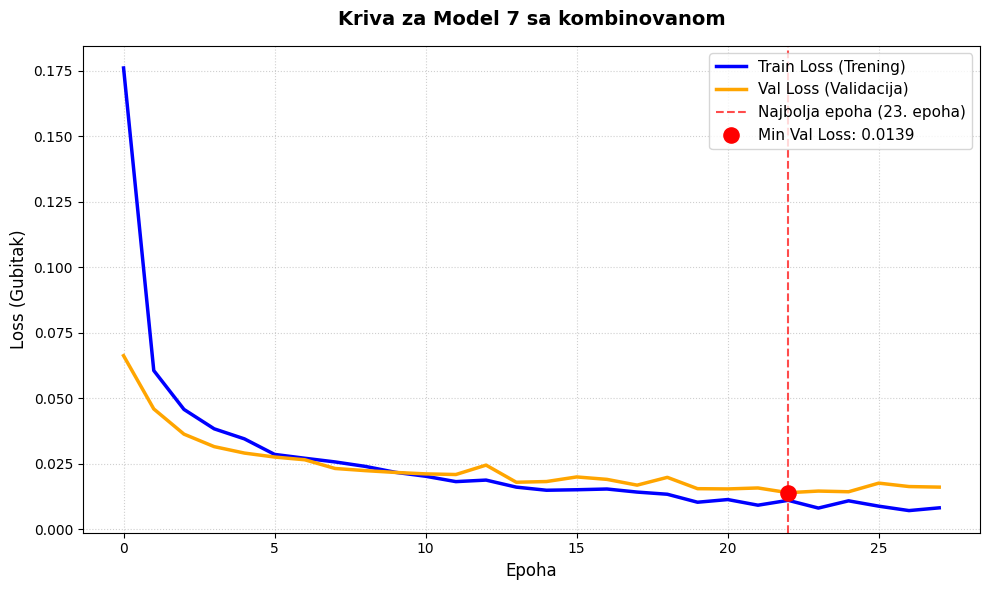

In [85]:
import numpy as np
import matplotlib.pyplot as plt

# Naziv  pobedničkog modela u rečniku
ime_pobednika = "Model_7_Kombinovano"

if ime_pobednika in istorija_eksperimenata:
    podaci = istorija_eksperimenata[ime_pobednika]

    # Kreiramo prostor za jedan veliki  grafikon
    plt.figure(figsize=(10, 6))

    # Crta liniju za trening i validacioni loss pobedničkog modela
    plt.plot(podaci["train_loss"], label="Train Loss (Trening)", color="blue", lw=2.5)
    plt.plot(podaci["val_loss"], label="Val Loss (Validacija)", color="orange", lw=2.5)

    # Pronalazimo indeks (epohu) i vrednost najboljeg validacionog gubitka
    najbolja_epoha = np.argmin(podaci["val_loss"])
    najbolji_loss = podaci["val_loss"][najbolja_epoha]

    # Vertikalna linija na mestu gde je Early Stopping uhvatio najbolji model
    plt.axvline(x=najbolja_epoha, color="red", linestyle="--", alpha=0.7,
                label=f"Najbolja epoha ({najbolja_epoha+1}. epoha)")

    # Istaknuta crvena tačka na samom dnu krive validacionog gubitka
    plt.scatter(najbolja_epoha, najbolji_loss, color="red", s=120, zorder=5,
                label=f"Min Val Loss: {najbolji_loss:.4f}")

    # Sređivanje naslova, oznaka i estetike grafikona
    plt.title(f"Kriva za Model 7 sa kombinovanom", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Epoha", fontsize=12)
    plt.ylabel("Loss (Gubitak)", fontsize=12)
    plt.legend(fontsize=11, loc="upper right")
    plt.grid(True, linestyle=":", alpha=0.6)

    plt.tight_layout()
    plt.show()
else:
    print(f"Greška: Ključ '{ime_pobednika}' nije pronađen u istoriji eksperimenata!")
    print("Dostupni modeli u memoriji su:", list(istorija_eksperimenata.keys()))

Evaluacija

In [86]:
finalni_model = FraudDetectionClass(
    input_dim=X_train.shape[1],
    hidden1=128,
    hidden2=64,
    dropout_rate=0.1
)

ime_fajla_modela = "model_7_kombinovano.pth"

try:
    finalni_model.load_state_dict(torch.load(ime_fajla_modela, weights_only=True))
    print(f" Uspešno učitane težine iz fajla: '{ime_fajla_modela}'\n")
except FileNotFoundError:
    print(f"\n GRESKA: Računar i dalje ne vidi fajl '{ime_fajla_modela}' u ovom folderu!")
    import os
    print("Trenutni folder u kome se nalaziš je:", os.getcwd())
    print("Fajlovi koje Python vidi u ovom folderu su:", [f for f in os.listdir() if f.endswith('.pth')])
    raise

# 3. Prebacujemo model u eval režim (gasi se dropout, svi neuroni su budni)
finalni_model.eval()

all_probs = []   # Za procente verovatnoće
all_preds = []   # Za binarne odluke (0 ili 1)
all_labels = []  # Za stvarna rešenja iz baze

# Gasimo računanje gradijenata radi brzine i uštede memorije
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        # Dobijamo sirove izlaze (logite) iz modela
        # Dodajemo .squeeze() ili ostavljamo kako mreža zahteva
        logits = finalni_model(X_batch)

        # Ako izlaz ima dimenziju [batch_size, 1], skidamo tu jedinicu da bude čist niz
        if len(logits.shape) > 1 and logits.shape[1] == 1:
            logits = logits.squeeze(1)

        # Primenjujemo Sigmoid da pretvorimo logite u verovatnoće (0.0 - 1.0)
        probs = torch.sigmoid(logits)

        # Donosimo odluku: sve preko ili jednako 0.5 je Prevara
        preds = (probs >= 0.5).float()

        # Skupljamo rezultate
        all_probs.extend(probs.numpy())
        all_preds.extend(preds.numpy())
        all_labels.extend(y_batch.numpy())

# Pretvaramo u NumPy nizove i ravnamo ih (.flatten()) da izbegnemo greške u sklearn-u
all_probs = np.array(all_probs).flatten()
all_preds = np.array(all_preds).flatten()
all_labels = np.array(all_labels).flatten()

print(f"Broj test primera: {len(all_labels)}")
print(f"Broj predviđenih prevara: {int(all_preds.sum())}")
print(f"Broj stvarnih prevara: {int(all_labels.sum())}\n")

 Uspešno učitane težine iz fajla: 'model_7_kombinovano.pth'

Broj test primera: 2000
Broj predviđenih prevara: 24
Broj stvarnih prevara: 30



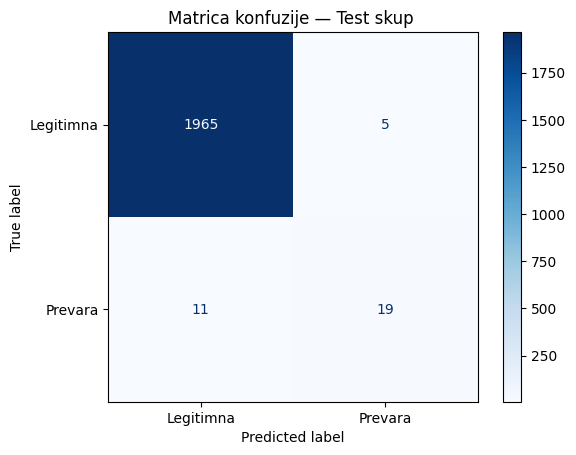

Matrica konfuzije (sirovi brojevi):
[[1965    5]
 [  11   19]]

True Negative (TN)  — tačno predviđeno LEGITIMNO: 1965
False Positive (FP) — pogrešno označeno kao FRAUD:  5
False Negative (FN) — propuštena prevara:           11
True Positive (TP)  — tačno predviđeno FRAUD:       19


In [87]:
# Matrica konfuzije
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimna', 'Prevara'])
disp.plot(cmap="Blues", values_format='d')
plt.title("Matrica konfuzije — Test skup ")
plt.show()

print("Matrica konfuzije (sirovi brojevi):")
print(cm)

# Raščlanjivanje na 4 kategorije
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negative (TN)  — tačno predviđeno LEGITIMNO: {tn}")
print(f"False Positive (FP) — pogrešno označeno kao FRAUD:  {fp}")
print(f"False Negative (FN) — propuštena prevara:           {fn}")
print(f"True Positive (TP)  — tačno predviđeno FRAUD:       {tp}")

In [88]:
from sklearn.metrics import classification_report, accuracy_score

accuracy = accuracy_score(all_labels, all_preds)
print(f"Ukupna tačnost (Accuracy): {accuracy*100:.2f}%\n")

print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=['Legitimna', 'Prevara'], digits=4))

Ukupna tačnost (Accuracy): 99.20%

Classification Report:
              precision    recall  f1-score   support

   Legitimna     0.9944    0.9975    0.9959      1970
     Prevara     0.7917    0.6333    0.7037        30

    accuracy                         0.9920      2000
   macro avg     0.8930    0.8154    0.8498      2000
weighted avg     0.9914    0.9920    0.9916      2000



ROC-AUC: 0.9917
PR-AUC (Average Precision): 0.7892


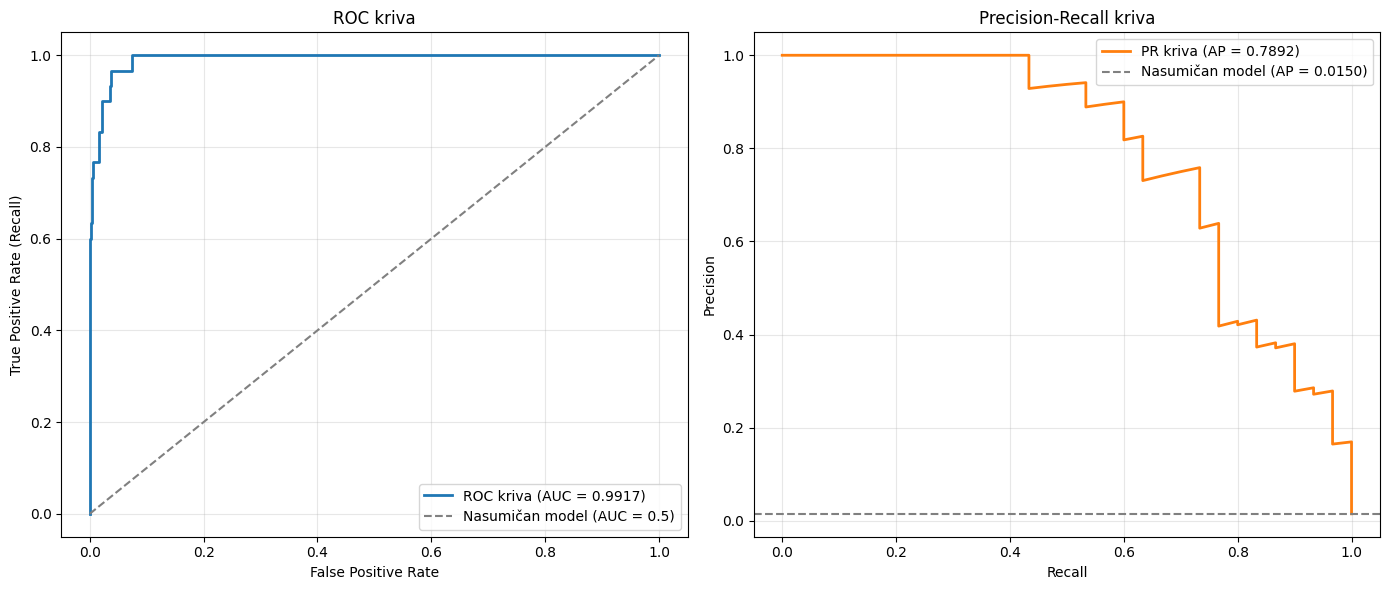

In [89]:
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, average_precision_score

# ROC-AUC meri koliko dobro model rangira transakcije po riziku, nezavisno od praga (0.5).
# Vrednost 0.5 = nasumičan model, 1.0 = savršen model.
roc_auc = roc_auc_score(all_labels, all_probs)
print(f"ROC-AUC: {roc_auc:.4f}")

# PR-AUC (Average Precision) je slična ideja, ali gleda samo na Precision/Recall.
# Kod jako neizbalansiranih podataka (mali % prevare) PR-AUC je realniji pokazatelj

pr_auc = average_precision_score(all_labels, all_probs)
print(f"PR-AUC (Average Precision): {pr_auc:.4f}")

# Pravimo dva grafikona jedan pored drugog
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

#LEVI GRAFIK: ROC kriva
# roc_curve nam vraća niz tačaka (FPR, TPR) za SVE moguće pragove od 0 do 1
fpr, tpr, _ = roc_curve(all_labels, all_probs)

axes[0].plot(fpr, tpr, color='#1f77b4', linewidth=2, label=f'ROC kriva (AUC = {roc_auc:.4f})')
# Isprekidana dijagonalna linija predstavlja model koji nasumično pogađa (AUC = 0.5) - referenca za poređenje
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Nasumičan model (AUC = 0.5)')
axes[0].set_xlabel('False Positive Rate')  # koliko lažnih uzbuna pravimo
axes[0].set_ylabel('True Positive Rate (Recall)')  # koliko stvarnih prevara hvatamo
axes[0].set_title('ROC kriva')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# DESNI GRAFIK: Precision-Recall kriva
# precision_recall_curve vraća niz (precision, recall) parova za sve pragove
precision, recall, _ = precision_recall_curve(all_labels, all_probs)

# Baseline za PR krivu NIJE 0.5 kao kod ROC, nego bazna stopa prevare u test skupu
# (npr. ako imaš 30 prevara od 2000 transakcija, baseline je 30/2000 = 0.015)
baseline_pr = all_labels.sum() / len(all_labels)

axes[1].plot(recall, precision, color='#ff7f0e', linewidth=2, label=f'PR kriva (AP = {pr_auc:.4f})')
axes[1].axhline(y=baseline_pr, color='gray', linestyle='--', label=f'Nasumičan model (AP = {baseline_pr:.4f})')
axes[1].set_xlabel('Recall')     # koliko od svih stvarnih prevara smo uhvatili
axes[1].set_ylabel('Precision')  # koliko su naše "fraud" oznake pouzdane
axes[1].set_title('Precision-Recall kriva')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

ROC-AUC = 0.9917
Kriva se skoro odmah penje uz levu ivicu pa ide pravo ka gornjem desnom uglu. U praktičnom smislu: ako uzmeš jednu nasumičnu prevaru i jednu nasumičnu legitimnu transakciju,model će u 99.17% slučajeva dodeliti veću verovatnocu prevari. Model dobro razdvaja klase po rangu.
kod ovako neizbalansiranog dataseta (1.5% prevara), ROC-AUC ume da bude preterano optimistična metrika, pa je bitnije pogledati PR krivu.
PR-AUC (Average Precision) = 0.7892
Ovo je realniji i stroži pokazatelj. Baseline (isprekidana siva linija) je na 0.015 — to je koliko bi imao nasumičan model bez ikakvog znanja. Ovaj model ima 0.7892, što je više od 50x bolje od nasumičnog. Ovo je jako solidan rezultat za fraud detection zadatak.



Levi deo krive (recall 0-0.6): precision ostaje na 1.0, to znači da za dosta niske pragove, model je apsolutno siguran i taman u pravu kad kaže "fraud". Nema lažnih uzbuna dok pokušavaš da uhvatiš prvih 60% prevara.
Nagli pad oko recall  0.6-0.65 — precision naglo pada sa 1.0 na 0.75. Ovo je tačka gde model počinje da se muči  — preostale prevare koje nije uhvatio su verovatno teži, granični slučajevi (možda liče na legitimne transakcije).
Nastavak pada nakon recall ≈ 0.8 — precision opada strmo do ~0.2-0.4, znači da bi se za hvatanje poslednjih par prevara (recall→1.0) moralo da prihvatiti dosta lažnih uzbuna(fp).

In [90]:
pragovi = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

rezultati_pragovi = []

for prag in pragovi:
    preds_t = (all_probs >= prag).astype(float)

    tn_t, fp_t, fn_t, tp_t = confusion_matrix(all_labels, preds_t).ravel()

    precision_t = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0
    recall_t    = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0
    f1_t = 2 * precision_t * recall_t / (precision_t + recall_t) if (precision_t + recall_t) > 0 else 0

    rezultati_pragovi.append({
        "Prag": prag, "TP": tp_t, "FP": fp_t, "FN": fn_t,
        "Precision": round(precision_t, 4),
        "Recall":    round(recall_t, 4),
        "F1":        round(f1_t, 4)
    })

df_pragovi = pd.DataFrame(rezultati_pragovi)
print("\n=== TABELA REZULTATA PO PRAGOVIMA ===")
print(df_pragovi.to_string(index=False))


=== TABELA REZULTATA PO PRAGOVIMA ===
 Prag  TP  FP  FN  Precision  Recall     F1
  0.1  24  32   6     0.4286  0.8000 0.5581
  0.2  23  23   7     0.5000  0.7667 0.6053
  0.3  22  11   8     0.6667  0.7333 0.6984
  0.4  22   7   8     0.7586  0.7333 0.7458
  0.5  19   5  11     0.7917  0.6333 0.7037
  0.6  18   3  12     0.8571  0.6000 0.7059
  0.7  16   2  14     0.8889  0.5333 0.6667


Prag 0.4 ima najveći F1 (0.7458), i to primetno bolji od trenutnog praga 0.5 (F1 = 0.7037). Ovo je matematički optimalna tačka balansa:
Prag 0.4:  TP=22, FP=7, FN=8  Precision 0.7586, Recall 0.7333, F1 0.7458
U poređenju sa pragom 0.5  (TP=19, FP=5, FN=11), prelaskom na 0.4 dobijamo:

+3 uhvaćene prevare (TP ide sa 19 na 22, tj. propuštaš 8 umesto 11)
+2 lažne uzbune (FP ide sa 5 na 7)
Neto efekat: bolji F1, bolji recall, uz malu žrtvu u precision (0.79 → 0.76)